In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Point to your dataset - update this path to match where your data extracted to
data_dir = r"C:\Users\ragha\Desktop\manufacturing-defect-detection\data\raw"

# List what's inside
for item in os.listdir(data_dir):
    print(item)

Matplotlib is building the font cache; this may take a moment.


archive
archive.zip


In [2]:
# Look inside the archive folder
archive_dir = r"C:\Users\ragha\Desktop\manufacturing-defect-detection\data\raw\archive"

for item in os.listdir(archive_dir):
    print(item)

casting_512x512
casting_data


In [3]:
# Look inside both folders
for folder in ["casting_512x512", "casting_data"]:
    path = os.path.join(archive_dir, folder)
    print(f"\n{folder}:")
    for item in os.listdir(path):
        print(f"  {item}")


casting_512x512:
  casting_512x512

casting_data:
  casting_data


In [4]:
# Go one level deeper
for folder in ["casting_512x512", "casting_data"]:
    path = os.path.join(archive_dir, folder, folder)
    print(f"\n{folder}:")
    for item in os.listdir(path):
        print(f"  {item}")


casting_512x512:
  def_front
  ok_front

casting_data:
  test
  train


In [5]:
# Count images in each class
base = r"C:\Users\ragha\Desktop\manufacturing-defect-detection\data\raw\archive\casting_data\casting_data"

for split in ["train", "test"]:
    print(f"\n{split}:")
    split_path = os.path.join(base, split)
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        count = len(os.listdir(cls_path))
        print(f"  {cls}: {count} images")


train:
  def_front: 3758 images
  ok_front: 2875 images

test:
  def_front: 453 images
  ok_front: 262 images


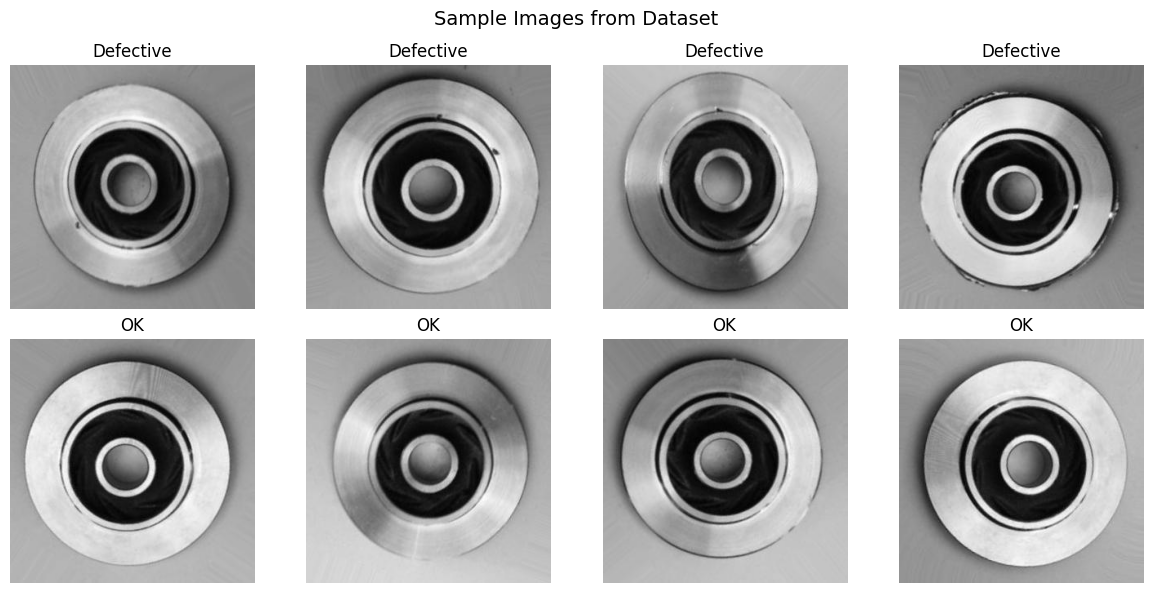

In [6]:
# Display sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Sample Images from Dataset", fontsize=14)

classes = ["def_front", "ok_front"]
labels = ["Defective", "OK"]

for row, (cls, label) in enumerate(zip(classes, labels)):
    cls_path = os.path.join(base, "train", cls)
    images = os.listdir(cls_path)[:4]
    
    for col, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"{label}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Check image dimensions
sample_path = os.path.join(base, "train", "def_front", os.listdir(os.path.join(base, "train", "def_front"))[0])
img = Image.open(sample_path)
print(f"Image size: {img.size}")
print(f"Image mode: {img.mode}")

Image size: (300, 300)
Image mode: RGB


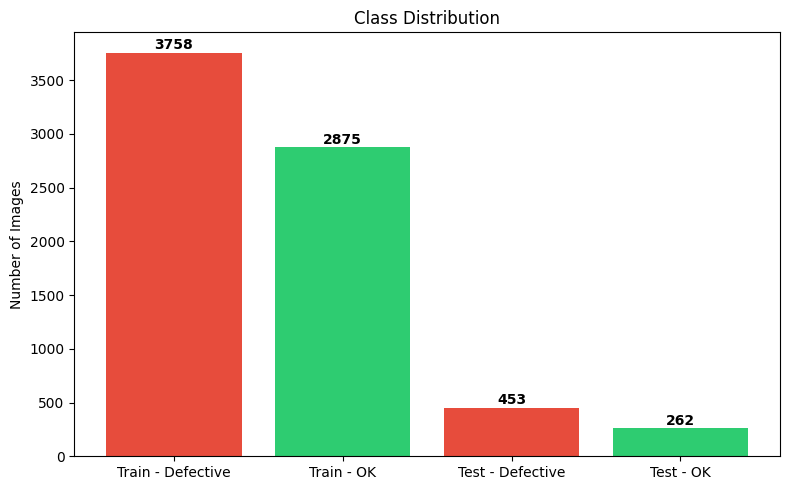

In [8]:
# Class balance chart
categories = ["Train - Defective", "Train - OK", "Test - Defective", "Test - OK"]
counts = [3758, 2875, 453, 262]
colors = ["#e74c3c", "#2ecc71", "#e74c3c", "#2ecc71"]

plt.figure(figsize=(8, 5))
bars = plt.bar(categories, counts, color=colors)
plt.title("Class Distribution")
plt.ylabel("Number of Images")
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(count), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()